In [7]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the slides quiet

import numpy as np
import matplotlib.pyplot as plt

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)

# Same canonical diagonal-Gram model as theorem_partii_clean_heavy_tail.ipynb.
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 0.0, "scale": 0.5},   # market-like factor
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
design = DesignSpec(
    n_values=[60],
    p_values=[200, 500, 1000, 2000, 5000, 10000, 20000],
    n_reps=300,
    random_seed=20260511,
    sampling="nested",
    # Heavy-tail variant: swap in student-t samplers, e.g.
    # factor_return_sampler={"distribution": "student_t", "df": 3, "loc": 0.0, "scale": 1.0},
    # idio_return_sampler={"distribution": "student_t", "df": 4, "loc": 0.0, "scale": 1.0},
)

df = run_experiment(model, design, DispersionBiasExperiment())

# Everything below is plotted as angles, to match the rotation_check deck.
def to_deg(v):
    """sin^2 of an angle -> the angle in degrees."""
    return np.degrees(np.arcsin(np.sqrt(np.clip(v, 0.0, 1.0))))

d = df.assign(ang_obs=to_deg(df["sin2_j"]), ang_pred=to_deg(df["rhs"]),
              ang_floor=to_deg(df["floor"]))
avg = d.groupby(["p", "j"])[["ang_obs", "ang_pred", "ang_floor"]].mean().reset_index()
P_VALUES = sorted(d["p"].unique())

NAVY, RED, GRAY = "#1f3864", "#c0392b", "#555555"
FACTOR_COLORS = ["tab:blue", "tab:orange", "tab:green"]
DEG_TICKS = ([0, 30, 60, 90], ["0\u00b0", "30\u00b0", "60\u00b0", "90\u00b0"])
print(f"rows: {len(df)}   p sweep: {P_VALUES}")

replicate: 100%|██████████| 300/300 [00:42<00:00,  7.01rep/s]

rows: 6300   p sweep: [200, 500, 1000, 2000, 5000, 10000, 20000]


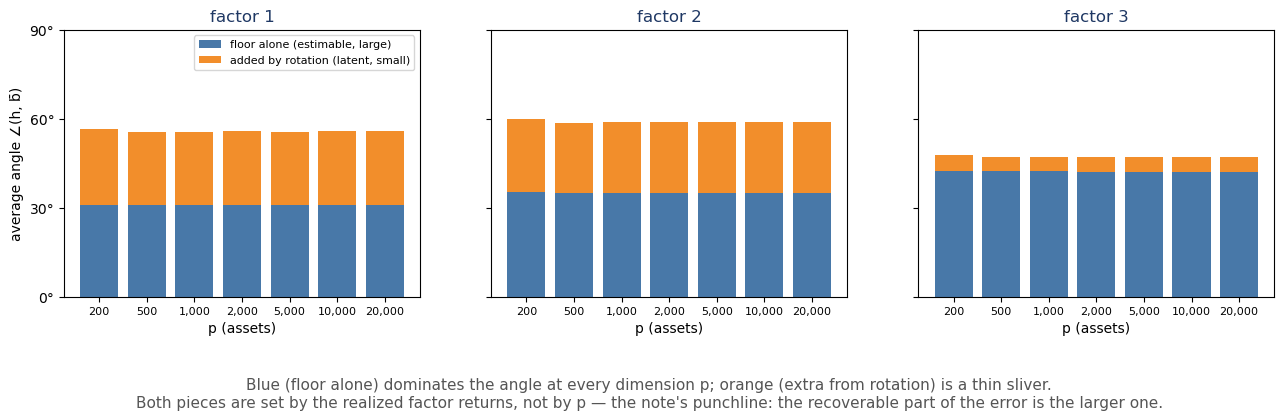

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.6), sharey=True)
fig.subplots_adjust(left=0.06, right=0.97, top=0.86, bottom=0.28)

x = np.arange(len(P_VALUES))
for j, ax in zip((1, 2, 3), axes):
    a = avg[avg["j"] == j].set_index("p").loc[P_VALUES]
    floor_part = a["ang_floor"].to_numpy()
    rotation_part = a["ang_pred"].to_numpy() - floor_part
    ax.bar(x, floor_part, color="#4878a8", label="floor alone (estimable, large)")
    ax.bar(x, rotation_part, bottom=floor_part, color="#f28e2b",
           label="added by rotation (latent, small)")
    ax.set_xticks(x, [f"{p:,}" for p in P_VALUES], fontsize=8)
    ax.set_ylim(0, 90)
    ax.set_yticks(*DEG_TICKS)
    ax.set_title(f"factor {j}", color=NAVY)
    ax.set_xlabel("p (assets)")
axes[0].set_ylabel("average angle \u2220(h, b\u0304)")
axes[0].legend(fontsize=8, loc="upper right")

fig.text(0.5, 0.04,
         "Blue (floor alone) dominates the angle at every dimension p; orange (extra from "
         "rotation) is a thin sliver.\nBoth pieces are set by the realized factor returns, "
         "not by p \u2014 the note's punchline: the recoverable part of the error is the larger one.",
         fontsize=11, color=GRAY, ha="center")

fig.savefig(OUT_DIR / "slide_partii_check_reveals.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Closed-form theoretical sin^2/angle(h_j, b_j) from the model parameters (no simulation).
# In the diagonal-Gram p->inf limit D_inf = diag(c_j * sigma_j^2) is diagonal, so its
# eigenvectors are exactly e_j: the rotation term sin^2/angle(w_j, e_j) vanishes and the
# theorem RHS collapses to the floor, delta^2 / (n*rho_j + delta^2), rho_j = c_j*sigma_j^2.
#   c_j       = E||beta_j||^2 / p = loc^2 + scale^2   (population prevalence of factor j)
#   sigma_j^2 = factor variance   (factor_vols squared, unless units="variance")
#   delta^2   = idio variance     (idio vol squared, unless units="variance")
_as_var = getattr(model, "units", "vol") == "variance"
_c_pop = np.array([s["loc"] ** 2 + s["scale"] ** 2 for s in model.beta_samplers])
_fvar = np.asarray(model.factor_vols, float) ** (1 if _as_var else 2)
_delta2 = model.idio_vol_sampler["value"] ** (1 if _as_var else 2)
RHO_POP = _c_pop * _fvar   # population spikes rho_j = c_j*sigma_j^2, one per factor
N_FIXED = design.n_values[0]   # n held fixed across the p sweep (= 60)
LABEL_THEO = r"theoretical $\sin^2\angle(h,\bar b)$: $\delta^2/(n\rho_j+\delta^2)$"

def theo_floor_deg(j, n):
    """Closed-form theoretical angle (h_j, b_j) in degrees, at this n (p->inf limit)."""
    return to_deg(_delta2 / (n * RHO_POP[j - 1] + _delta2))

print("theoretical floor angles (n=%d):" % N_FIXED,
      [round(float(theo_floor_deg(j, N_FIXED)), 1) for j in (1, 2, 3)], "deg")

def angle_bars(ax, cats, series, width=0.82):
    """Grouped vertical bars on a categorical x-axis.

    series: list of (label, values, color), each aligned to ``cats``.
    """
    x = np.arange(len(cats))
    m = len(series)
    bw = width / m
    for i, (label, vals, color) in enumerate(series):
        ax.bar(x + (i - (m - 1) / 2) * bw, vals, bw, label=label, color=color)
    ax.set_xticks(x, cats, fontsize=8)
    return x

theoretical floor angles (n=60): [32.8, 32.8, 40.7] deg


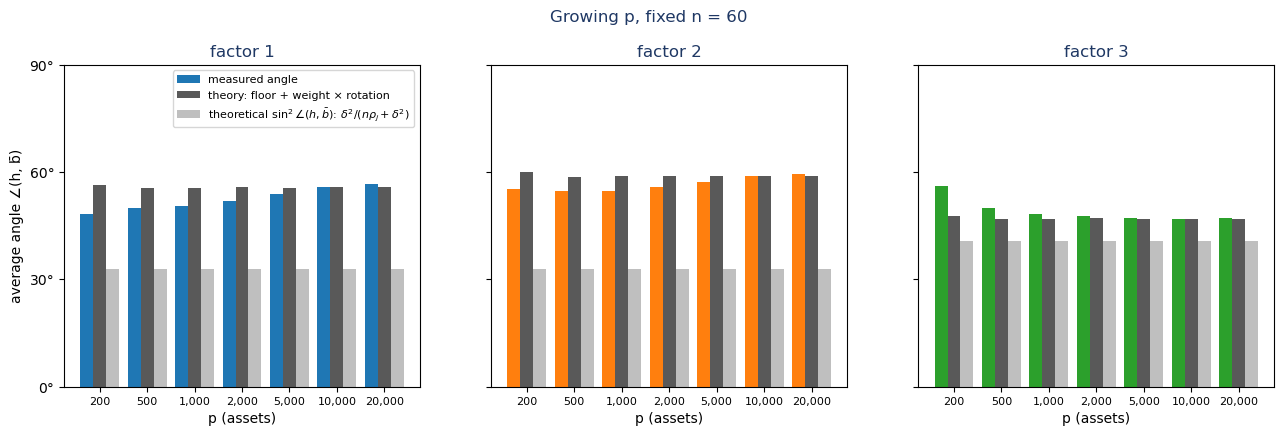

In [10]:
# Growing p, fixed n: same three quantities as grouped bars -- measured angle, the
# floor+weight*rotation prediction, and the closed-form theoretical floor.
# (reuses avg / P_VALUES from cell 1)
fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.6), sharey=True)
fig.subplots_adjust(left=0.06, right=0.97, top=0.86, bottom=0.16)
for j, ax in zip((1, 2, 3), axes):
    a = avg[avg["j"] == j].set_index("p").loc[P_VALUES]
    floor_vals = np.full(len(P_VALUES), theo_floor_deg(j, N_FIXED))
    angle_bars(ax, [f"{p:,}" for p in P_VALUES], [
        ("measured angle", a["ang_obs"].to_numpy(), FACTOR_COLORS[j - 1]),
        ("theory: floor + weight × rotation", a["ang_pred"].to_numpy(), "0.35"),
        (LABEL_THEO, floor_vals, "0.75"),
    ])
    ax.set_ylim(0, 90)
    ax.set_yticks(*DEG_TICKS)
    ax.set_title(f"factor {j}", color=NAVY)
    ax.set_xlabel("p (assets)")
    if j == 1:
        ax.set_ylabel("average angle ∠(h, b̄)")
        ax.legend(fontsize=8, loc="upper right")
    else:
        ax.tick_params(labelleft=False)
fig.suptitle(f"Growing p, fixed n = {N_FIXED}", color=NAVY, y=0.98)
plt.show()

replicate: 100%|██████████| 300/300 [00:23<00:00, 12.80rep/s]


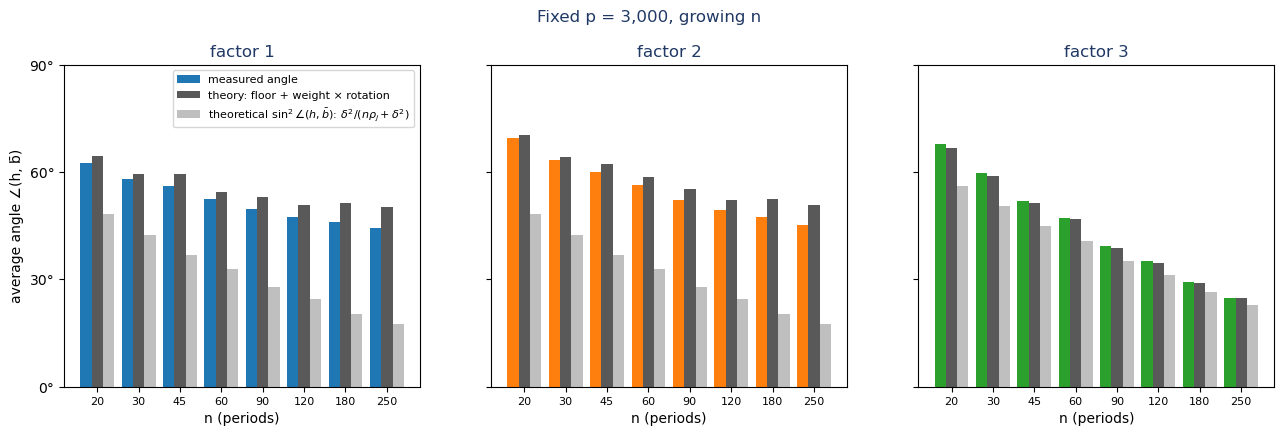

In [11]:
# Fixed p = 3000, growing n: hold the ambient dimension and sweep the sample length,
# shown as grouped bars. The theoretical floor (lightest bars) now falls with n.
P_FIXED = 3000
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 90, 120, 180, 250],
    p_values=[P_FIXED],
    n_reps=300,
    random_seed=20260511,
    sampling="nested",
)
df_n = run_experiment(model, design_n, DispersionBiasExperiment())

d_n = df_n.assign(ang_obs=to_deg(df_n["sin2_j"]), ang_pred=to_deg(df_n["rhs"]))
avg_n = d_n.groupby(["n", "j"])[["ang_obs", "ang_pred"]].mean().reset_index()
N_VALUES = sorted(d_n["n"].unique())

fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.6), sharey=True)
fig.subplots_adjust(left=0.06, right=0.97, top=0.86, bottom=0.16)
for j, ax in zip((1, 2, 3), axes):
    a = avg_n[avg_n["j"] == j].set_index("n").loc[N_VALUES]
    floor_vals = np.array([theo_floor_deg(j, n) for n in N_VALUES])
    angle_bars(ax, [str(n) for n in N_VALUES], [
        ("measured angle", a["ang_obs"].to_numpy(), FACTOR_COLORS[j - 1]),
        ("theory: floor + weight × rotation", a["ang_pred"].to_numpy(), "0.35"),
        (LABEL_THEO, floor_vals, "0.75"),
    ])
    ax.set_ylim(0, 90)
    ax.set_yticks(*DEG_TICKS)
    ax.set_title(f"factor {j}", color=NAVY)
    ax.set_xlabel("n (periods)")
    if j == 1:
        ax.set_ylabel("average angle ∠(h, b̄)")
        ax.legend(fontsize=8, loc="upper right")
    else:
        ax.tick_params(labelleft=False)
fig.suptitle(f"Fixed p = {P_FIXED:,}, growing n", color=NAVY, y=0.98)
plt.show()

replicate: 100%|██████████| 300/300 [00:14<00:00, 20.11rep/s]


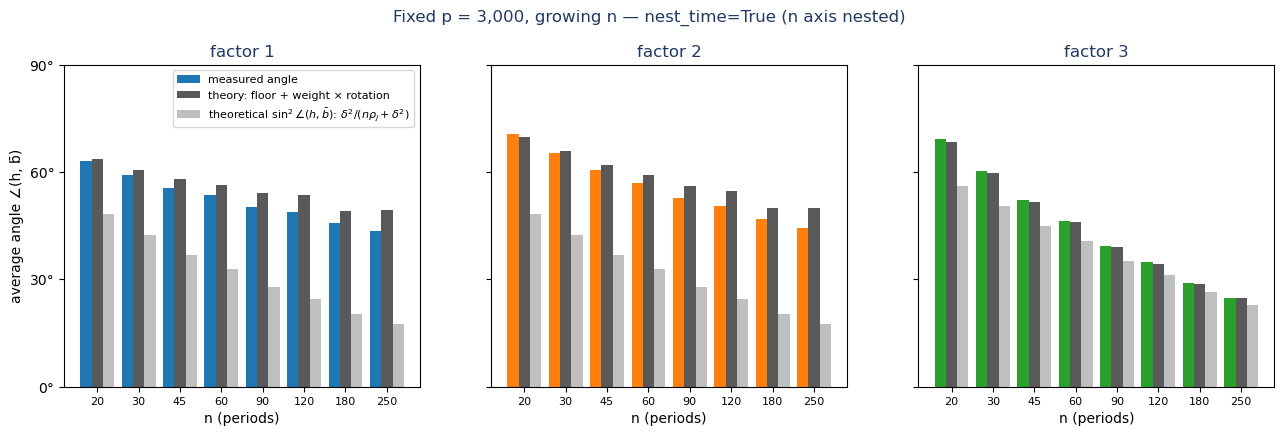

In [12]:
# Same fixed-p = 3000 sweep, but with nest_time=True: each replicate draws returns
# ONCE at n_max and every n is the first-n-periods prefix of that single draw, so the
# n-curve is nested (a monotone, lower-variance time analogue of the p nesting)
# instead of being redrawn independently for each n.
design_nt = DesignSpec(
    n_values=[20, 30, 45, 60, 90, 120, 180, 250],
    p_values=[P_FIXED],
    n_reps=300,
    random_seed=20260511,
    sampling="nested",
    nest_time=True,
)
df_nt = run_experiment(model, design_nt, DispersionBiasExperiment())

d_nt = df_nt.assign(ang_obs=to_deg(df_nt["sin2_j"]), ang_pred=to_deg(df_nt["rhs"]))
avg_nt = d_nt.groupby(["n", "j"])[["ang_obs", "ang_pred"]].mean().reset_index()
N_VALUES_NT = sorted(d_nt["n"].unique())

fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.6), sharey=True)
fig.subplots_adjust(left=0.06, right=0.97, top=0.86, bottom=0.16)
for j, ax in zip((1, 2, 3), axes):
    a = avg_nt[avg_nt["j"] == j].set_index("n").loc[N_VALUES_NT]
    floor_vals = np.array([theo_floor_deg(j, n) for n in N_VALUES_NT])
    angle_bars(ax, [str(n) for n in N_VALUES_NT], [
        ("measured angle", a["ang_obs"].to_numpy(), FACTOR_COLORS[j - 1]),
        ("theory: floor + weight × rotation", a["ang_pred"].to_numpy(), "0.35"),
        (LABEL_THEO, floor_vals, "0.75"),
    ])
    ax.set_ylim(0, 90)
    ax.set_yticks(*DEG_TICKS)
    ax.set_title(f"factor {j}", color=NAVY)
    ax.set_xlabel("n (periods)")
    if j == 1:
        ax.set_ylabel("average angle ∠(h, b̄)")
        ax.legend(fontsize=8, loc="upper right")
    else:
        ax.tick_params(labelleft=False)
fig.suptitle(f"Fixed p = {P_FIXED:,}, growing n — nest_time=True (n axis nested)",
             color=NAVY, y=0.98)
plt.show()